# Diffraction Exploration: Order and Disorder in a Finite Square Lattice

In this notebook, we explore how positional disorder in a finite 2D square lattice affects its diffraction pattern.

We begin with a perfect 10×10 lattice and then introduce increasing levels of random positional jitter. For each disorder level, we generate multiple random realizations so that we can observe both the overall trend and the variability within the same level of disorder.

The goal of this notebook is not to train a model yet. Instead, it is to build visual and physical intuition around a core question:

**Can diffraction patterns encode the degree of structural disorder in a stable and interpretable way?**

We will examine:

- the real-space lattice structure
- the corresponding diffraction intensity pattern
- how both evolve as positional disorder increases

This notebook focuses only on **positional disorder**. Other defect types such as vacancies or local distortions can be explored later.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def create_lattice(n_points=10, grid_size=128, jitter_sigma=0.0):
    img = np.zeros((grid_size, grid_size))

    spacing = grid_size / (n_points + 2)

    # ideal lattice coordinates before centering
    coords = np.arange(n_points) * spacing
    lattice_span = coords[-1] - coords[0]

    # center the lattice block in the image
    start = (grid_size - lattice_span) / 2.0

    for i in range(n_points):
        for j in range(n_points):
            x = start + i * spacing
            y = start + j * spacing

            x += np.random.normal(0, jitter_sigma * spacing)
            y += np.random.normal(0, jitter_sigma * spacing)

            xi = int(np.clip(round(x), 0, grid_size - 1))
            yi = int(np.clip(round(y), 0, grid_size - 1))

            img[yi, xi] = 1.0

    return img

In [6]:
def compute_diffraction(img):
    F = np.fft.fftshift(np.fft.fft2(img))
    I = np.abs(F)**2
    I_log = np.log1p(I)
    return I_log

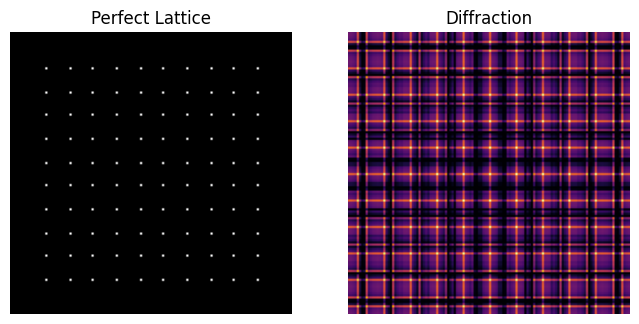

In [7]:
img = create_lattice(n_points=10, jitter_sigma=0.0)
diff = compute_diffraction(img)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Perfect Lattice")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(diff, cmap='inferno')
plt.title("Diffraction")
plt.axis('off')

plt.show()

In [9]:
sigmas = [0.00, 0.05, 0.10, 0.15, 0.20]
n_realizations = 4

In [10]:
samples = []

for sigma in sigmas:
    sigma_samples = []
    for _ in range(n_realizations):
        img = create_lattice(n_points=10, jitter_sigma=sigma)
        diff = compute_diffraction(img)
        sigma_samples.append((img, diff))
    samples.append(sigma_samples)

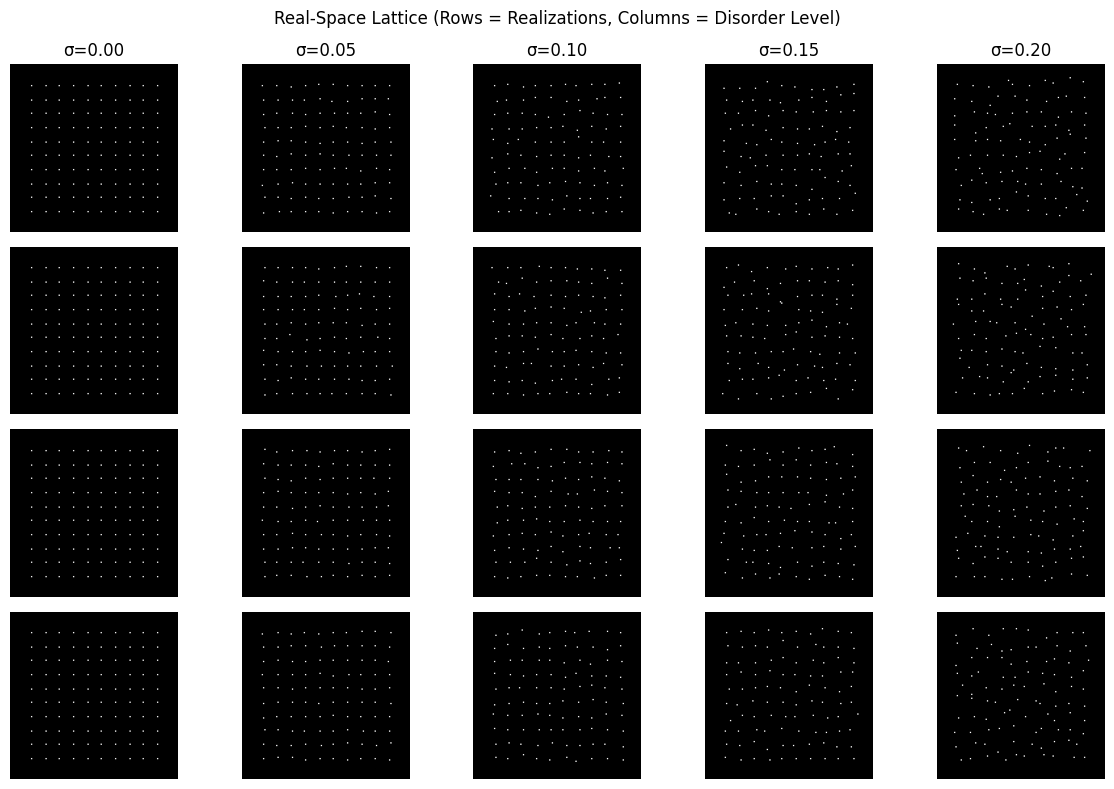

In [11]:
fig, axes = plt.subplots(n_realizations, len(sigmas), figsize=(12, 8))

for col, sigma in enumerate(sigmas):
    for row in range(n_realizations):
        img, _ = samples[col][row]

        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')

        if row == 0:
            axes[row, col].set_title(f"σ={sigma:.2f}")

plt.suptitle("Real-Space Lattice (Rows = Realizations, Columns = Disorder Level)")
plt.tight_layout()
plt.show()

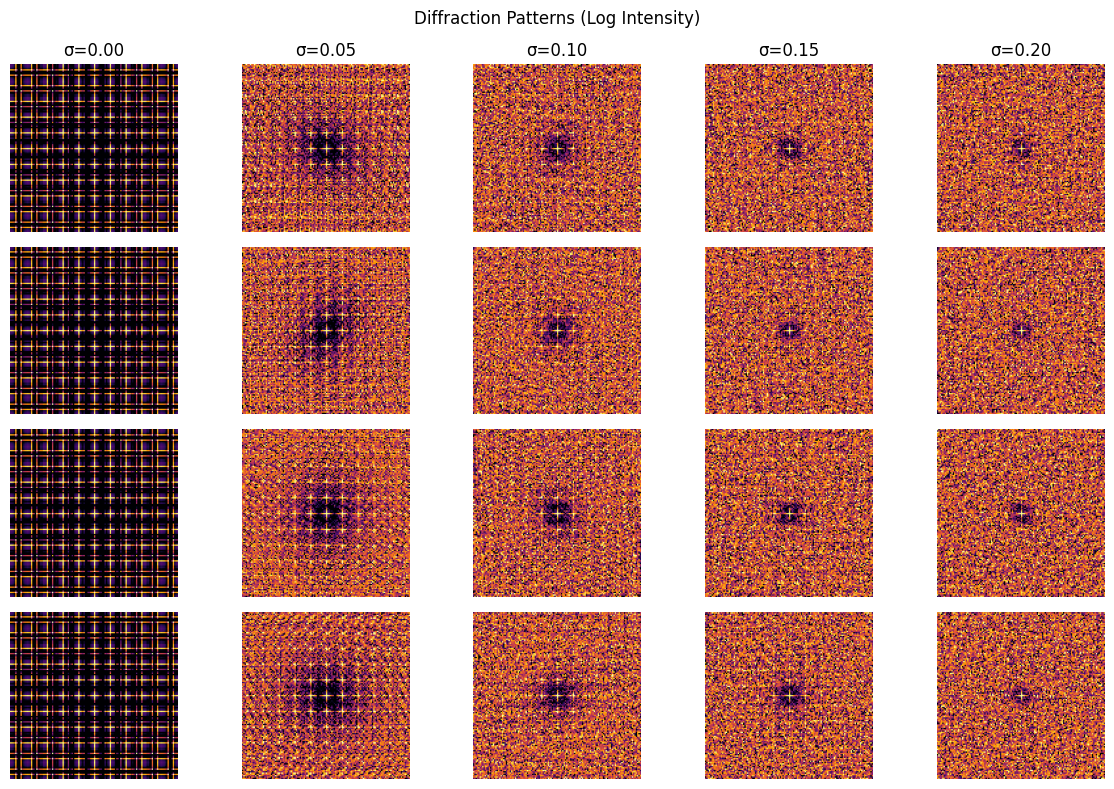

In [13]:
fig, axes = plt.subplots(n_realizations, len(sigmas), figsize=(12, 8))

vmin = np.percentile(diff, 5)
vmax = np.percentile(diff, 99)

for col, sigma in enumerate(sigmas):
    for row in range(n_realizations):
        _, diff = samples[col][row]

        axes[row, col].imshow(diff, cmap='inferno', vmin=vmin, vmax=vmax)
        axes[row, col].axis('off')

        if row == 0:
            axes[row, col].set_title(f"σ={sigma:.2f}")

plt.suptitle("Diffraction Patterns (Log Intensity)")
plt.tight_layout()
plt.show()